In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#569CC6", "#D55F03"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55F03", "#569CC6", "#13A076"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55F03", "#569CC6", "#13A076", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55F03", "#569CC6", "#13A076", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [2]:
import sys
!{sys.executable} -m pip install -U mlforecast


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from itertools import combinations
from functools import partial
from typing import Optional

from mlforecast import MLForecast
from mlforecast.target_transforms import GlobalSklearnTransformer
from mlforecast.utils import PredictionIntervals
from scipy import stats
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
from sklearn.preprocessing import FunctionTransformer
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from utilsforecast.feature_engineering import fourier, pipeline, trend

from fpppy.models import LinearRegression


mpl.rcParams['axes.prop_cycle'] = cycler(color=["#569CC6", "#D55F03", "#13A076"])

def plot_diagnostics(
    forecaster,
    model: Optional[str] = None,
    n_lags: int = None,
    target_col: str = "y",
    time_col: str = "ds",
):
    # Plot first model only if no model spec is given
    if model is None:
        model = list(forecaster.models.keys())[0]
    fitted = forecaster.forecast_fitted_values().assign(
        resid=lambda x: x[target_col] - x[model]
    )

    _, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])

    ax = axes["resid"]
    ax.plot(fitted[time_col], fitted["resid"], marker='.')
    ax.set(title="Innovation Residuals")

    ax = axes["acf"]
    plot_acf(
        fitted["resid"], ax=ax, zero=False, lags=n_lags,
        bartlett_confint=False, auto_ylims=True)
    ax.set(title="ACF Plot", xlabel="lag[1]", ylabel='acf')

    ax = axes["hist"]
    ax.hist(fitted["resid"], bins=20)
    ax.set(title="Histogram", xlabel="resid", ylabel="count")

def adj_r2_score(y, y_hat, T, k):
    r2 = r2_score(y, y_hat)
    return 1 - (1 - r2) * (T - 1) / (T - k - 1)

def aic_score(y, y_hat, T, k):
    sse = np.sum((y - y_hat) ** 2)
    return T * np.log(sse / T) + 2 * (k + 2)

def aicc_score(y, y_hat, T, k):
    aic = aic_score(y, y_hat, T, k)
    return aic + (2 * (k + 2) * (k + 3)) / (T - k - 3)

def bic_score(y, y_hat, T, k):
    sse = np.sum((y - y_hat) ** 2)
    return T * np.log(sse / T) + (k + 2) * np.log(T)

def cv_score(mf, model='LinearRegression'):
    fitted_model = mf.models_[model]
    X = fitted_model._X_design  
    y = fitted_model._y
    e = fitted_model._residuals
    XtX_inv = np.linalg.pinv(X.T @ X)
    h = np.sum((X @ XtX_inv) * X, axis=1) 
    return np.nanmean((e / (1 - h))**2)

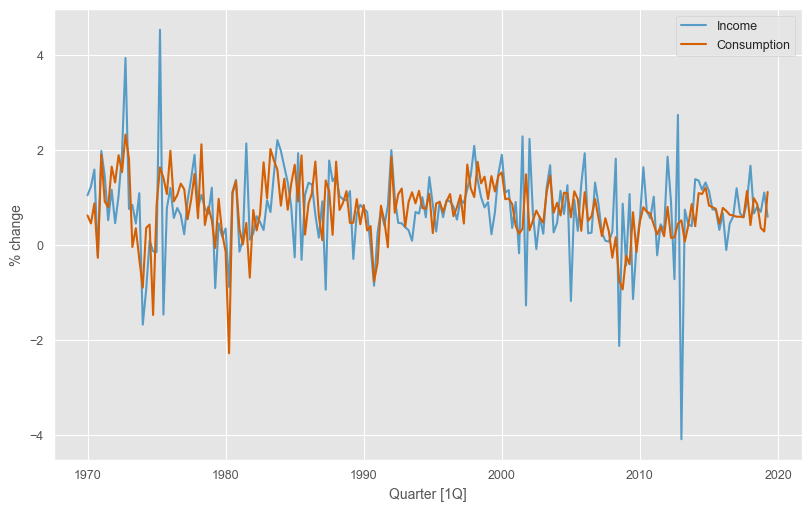

In [4]:
us_change = pd.read_csv("US_change.csv", parse_dates=["ds"])

fig, ax = plt.subplots()
ax.plot(us_change["ds"], us_change["Income"], label="Income")
ax.plot(us_change["ds"], us_change["y"], label="Consumption")
ax.set(xlabel="Quarter [1Q]", ylabel="% change")
ax.legend()
plt.show()

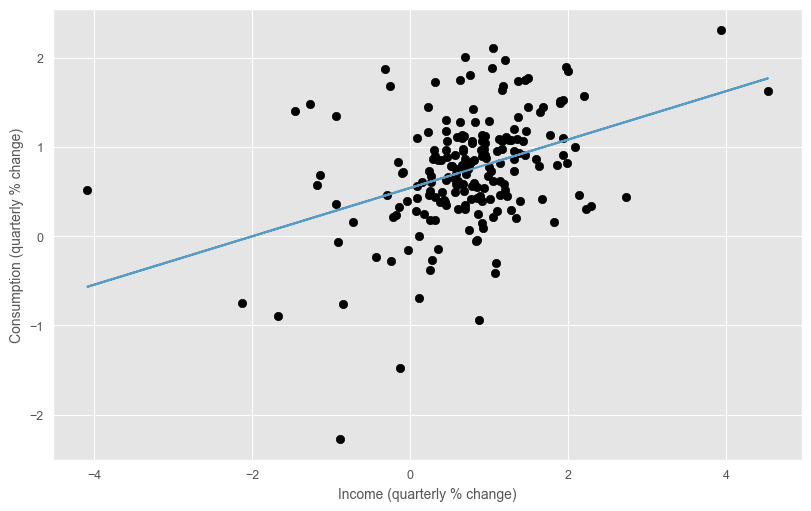

In [5]:
mf = MLForecast(models=LinearRegression(), freq="QS-OCT")
mf.fit(us_change[["ds", "y", "unique_id", "Income"]],
    fitted=True, static_features=[])

fig, ax = plt.subplots()
ax.scatter(us_change["Income"], us_change["y"], color="k")
ax.plot(us_change["Income"],
    mf.forecast_fitted_values()["LinearRegression"])
ax.set(
    xlabel="Income (quarterly % change)",
    ylabel="Consumption (quarterly % change)")
plt.show()

In [6]:
def print_regression_summary_from_model(model):
    X = model._X.values.astype(float)
    y = model._y
    resid = model._residuals

    n, p = X.shape
    X_design = np.hstack([np.ones((n, 1)), X])
    dof = n - p - 1

    # residuals summary
    percentiles = [0, 25, 50, 75, 100]
    labels = ["Min", "1Q", "Median", "3Q", "Max"]
    percentiles_resid = np.percentile(resid, percentiles)
    resid_summary = pd.DataFrame({
        label: [percentile]
        for (label, percentile) in zip(labels, percentiles_resid)
    }, index=[""])

    # coefficients summary
    coef = np.insert(model.coef_, 0, model.intercept_)
    rss = np.sum(resid**2)
    mse = rss / dof
    var_beta = mse * np.linalg.inv(X_design.T @ X_design).diagonal()
    se_beta = np.sqrt(var_beta)
    t_stats = coef / se_beta
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), dof))
    names = ["(Intercept)"] + model._var_names
    stars_lookup = ["***", "**", "*", "."]
    stars_conds = [
        p_values < 0.001, p_values < 0.01,
        p_values < 0.05, p_values < 0.1]
    stars = np.select(stars_conds, stars_lookup, default="")
    coef_summary = pd.DataFrame({
        "Estimate": coef, "Std. Error": se_beta, 
        "t value": t_stats, "Pr(>|t|)": p_values, "": stars
    }, index=names)

    # more statistics
    r_squared = model.score(X, y)
    adj_r_squared = 1 - (1 - r_squared) * (n - 1) / dof
    f_stat = (r_squared / p) / ((1 - r_squared) / dof)
    f_pval = 1 - stats.f.cdf(f_stat, p, dof)

    # print the report
    print(f"Residuals:\n{resid_summary}\n\nCoefficients:\n{coef_summary}")
    print(f"---")
    signif_code_str = "0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1"
    print(f"Signif. codes: {signif_code_str}\n")

    print(
        f"Residual standard error: {np.sqrt(mse):.3f}",
        f"on {dof} degrees of freedom",
        f"\nMultiple R-squared: {r_squared:.3f},   ",
        f"Adjusted R-squared: {adj_r_squared:.3f}",
        f"\nF-statistic: {f_stat:.1f} on {p}",
        f"and {dof} DF, p-value: {f_pval:.3g}")

print_regression_summary_from_model(mf.models_["LinearRegression"])

Residuals:
    Min     1Q  Median     3Q    Max
 -2.582 -0.278   0.019  0.323  1.422

Coefficients:
             Estimate  Std. Error  t value   Pr(>|t|)     
(Intercept)     0.545       0.054   10.079  0.000e+00  ***
Income          0.272       0.047    5.817  2.402e-08  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.591 on 196 degrees of freedom 
Multiple R-squared: 0.147,    Adjusted R-squared: 0.143 
F-statistic: 33.8 on 1 and 196 DF, p-value: 2.4e-08


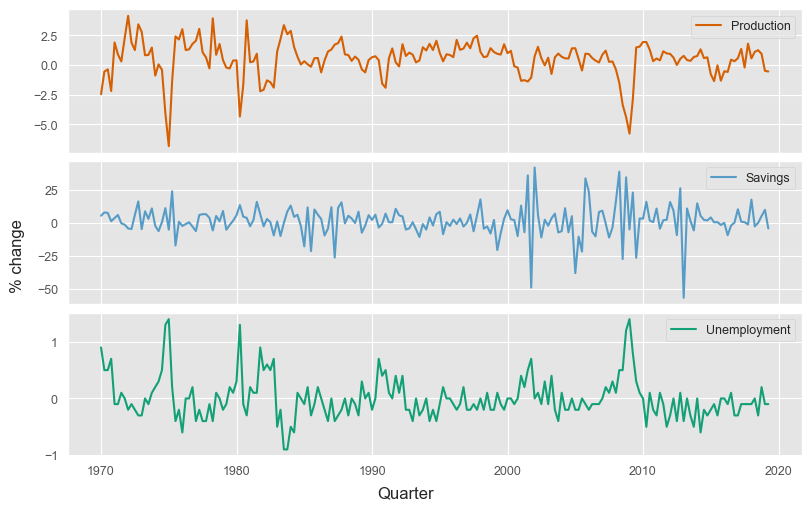

In [7]:
fig, axes = plt.subplots(nrows=3, ncols=1, sharex=True)
sns.lineplot(data=us_change, x="ds", y="Production", ax=axes[0],
    color="#D55F03", label="Production")
sns.lineplot(data=us_change, x="ds", y="Savings", ax=axes[1],
    color="#569CC6", label="Savings")
sns.lineplot(data=us_change, x="ds", y="Unemployment", ax=axes[2],
    color="#13A076", label="Unemployment")
for ax in axes:
    ax.set(xlabel="", ylabel="")
fig.supxlabel("Quarter")
fig.supylabel("% change")
plt.show()

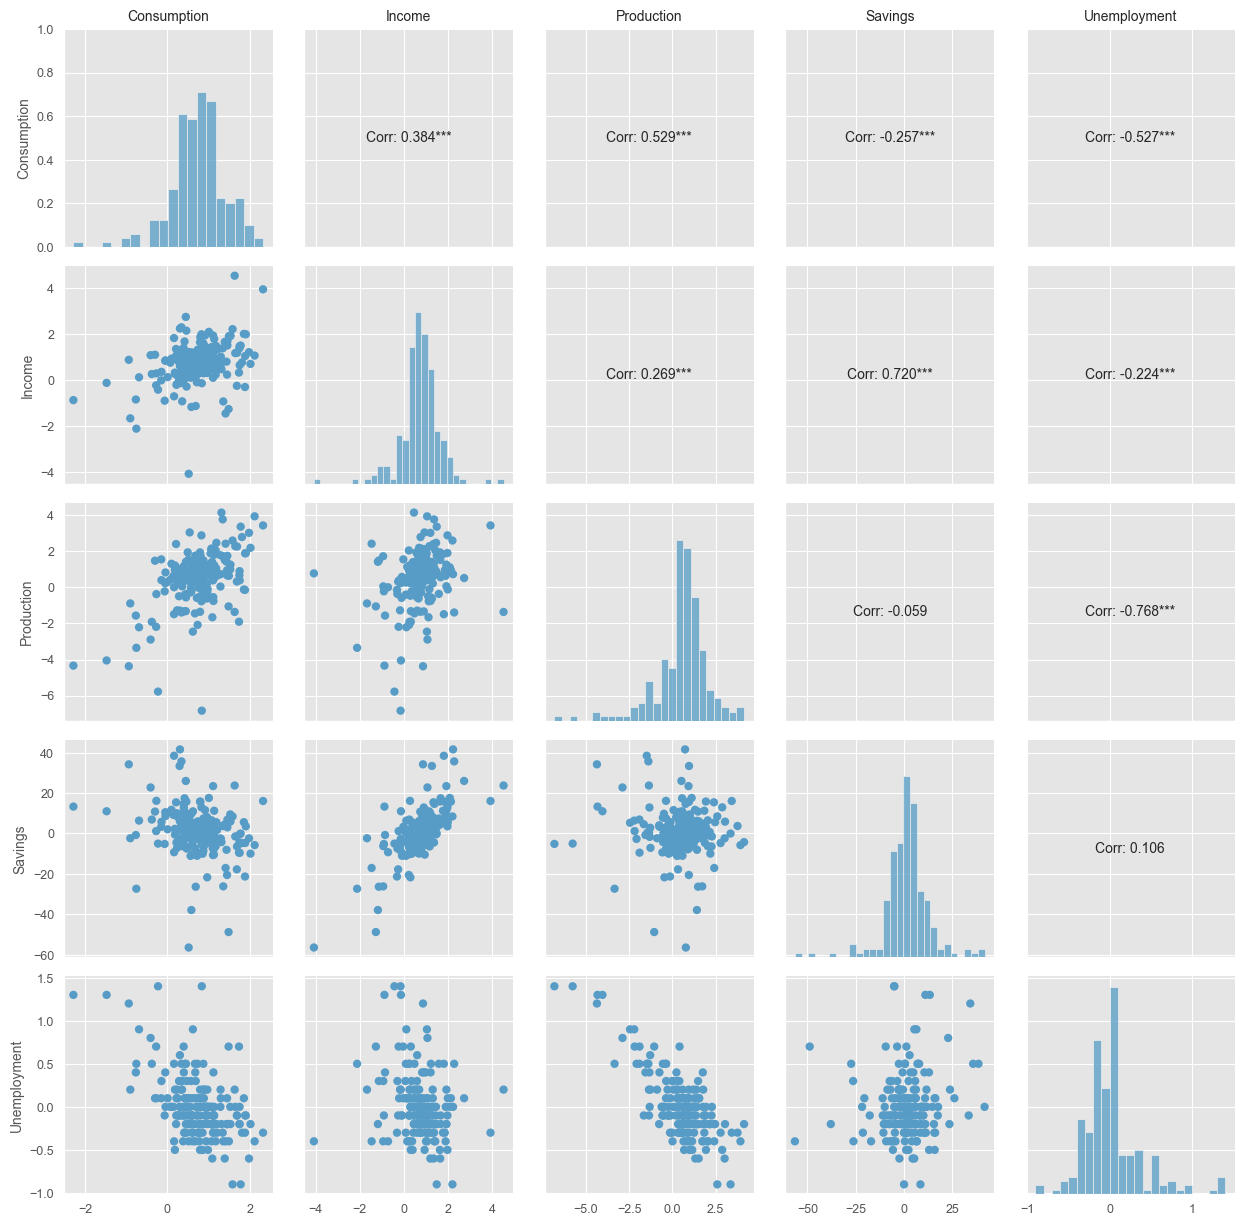

In [8]:
columns = ["y", "Income", "Production", "Savings", "Unemployment"]
df = us_change[columns].rename(columns={'y': 'Consumption'})

def corrfunc(x, y, **kws):
    r, pvalue = pearsonr(x, y)
    ax = plt.gca()
    ax.annotate(
        f"Corr: {r:.3f}{'***' if pvalue < 0.05 else ''}",
        xy=(0.5, 0.5), xycoords="axes fraction",
        ha="center", va="center")

g = sns.PairGrid(df)
g.map_diag(sns.histplot)
g.map_upper(corrfunc)
g.map_lower(sns.scatterplot, edgecolor="none")
g.add_legend()
# Move x-axis labels to the top
g.set(xlabel="")
for i, col in enumerate(df.columns):
    g.axes[0, i].set_title(col, size='medium')
plt.show()

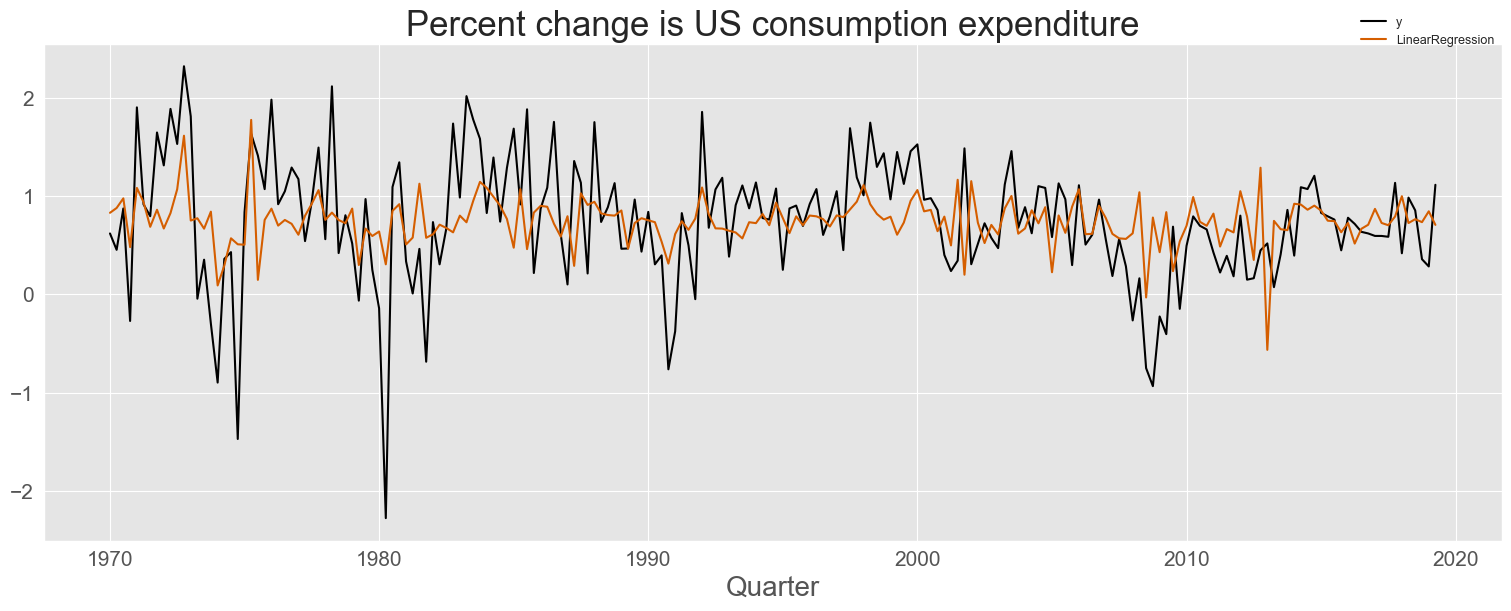

In [9]:
df = mf.forecast_fitted_values().drop(columns="y")
plot_series(us_change, df,
    xlabel="Quarter", ylabel="",
    title="Percent change is US consumption expenditure",
    palette="black_and_orange", rm_legend=False)

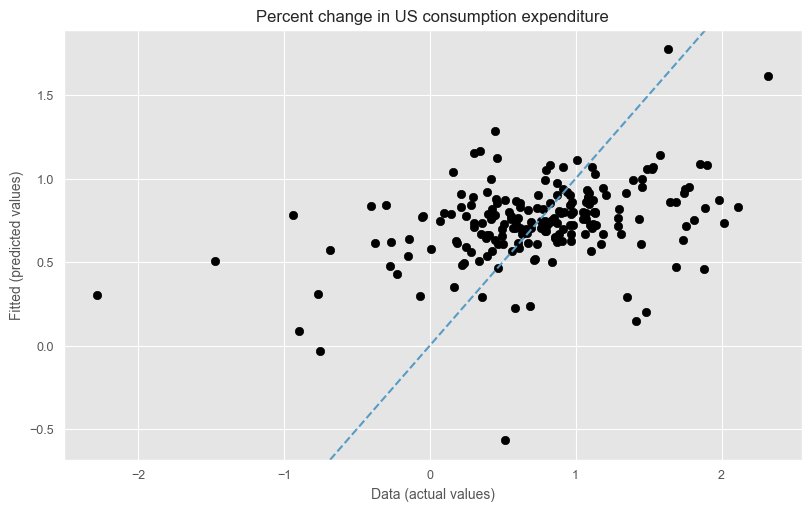

In [10]:
fig, ax = plt.subplots()
insample_forecasts = mf.forecast_fitted_values()["LinearRegression"]
ax.scatter(us_change["y"], insample_forecasts, color="k")
ax.axline((0, 0), (1, 1), linestyle="--")
ax.set(
    title="Percent change in US consumption expenditure",
    xlabel="Data (actual values)",
    ylabel="Fitted (predicted values)")
plt.show()

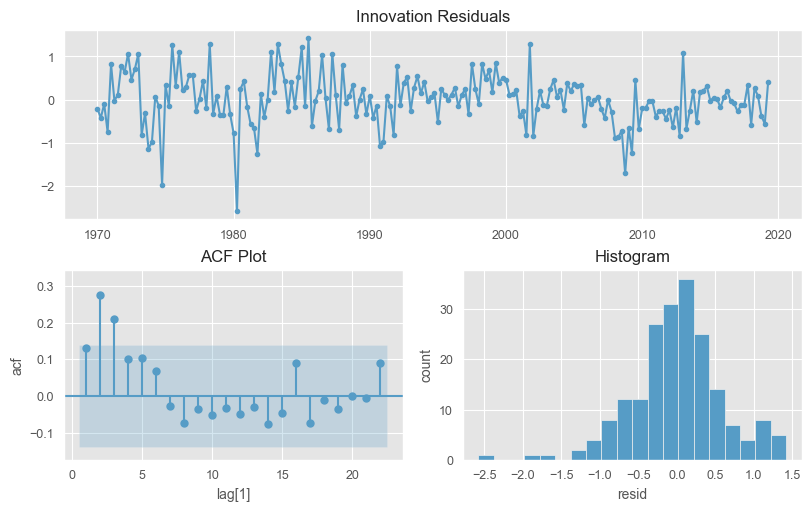

In [11]:
plot_diagnostics(forecaster=mf, n_lags=22)

In [12]:
residuals = mf.models_["LinearRegression"]._residuals
acorr_ljungbox(residuals, lags=[10])

,lb_stat,lb_pvalue
10,35.078,1.211e-04


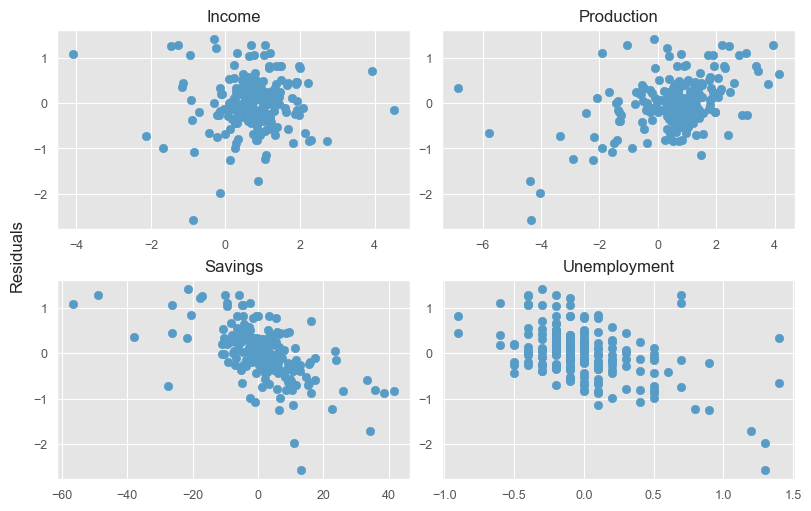

In [13]:
fig, axes = plt.subplots(nrows=2, ncols=2)
columns = ["Income", "Production", "Savings", "Unemployment"]
for ax, column in zip(axes.ravel(), columns):
    ax.scatter(us_change[column], residuals)
    ax.set(title=column)
fig.supylabel("Residuals")
plt.show()

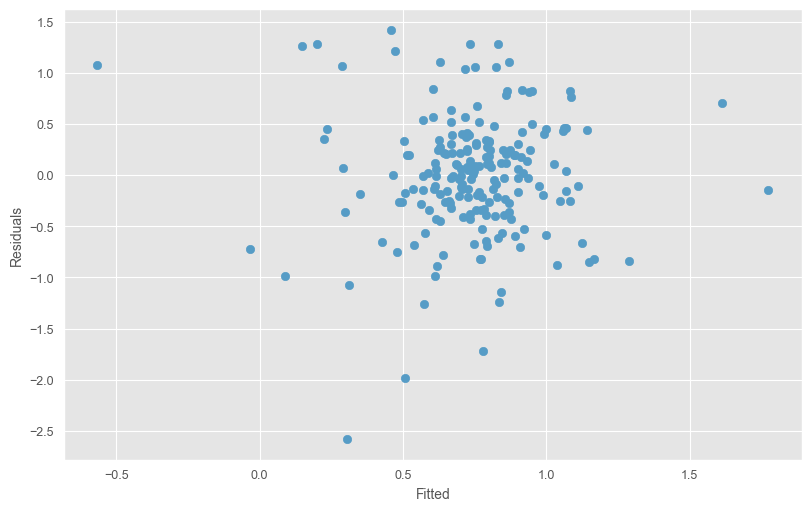

In [14]:
fig, ax = plt.subplots()
ax.scatter(insample_forecasts, residuals)
ax.set(xlabel="Fitted", ylabel="Residuals")
plt.show()

In [15]:
aus_airpassengers = pd.read_csv("aus_airpassengers.csv",
    index_col=0, parse_dates=["Year"])
guinea_rice = pd.read_csv("guinea_rice.csv",
    index_col=0, parse_dates=["Year"])
aus_airpassengers = (
    aus_airpassengers
    .merge(guinea_rice, on="Year")
    .assign(unique_id="AirPassengers")
)

mf = MLForecast(models=LinearRegression(), freq="YS")
mf.fit(aus_airpassengers, time_col="Year", target_col="Passengers",
    fitted=True, static_features=[])

insample = mf.forecast_fitted_values().assign(
    resid=lambda x: x["Passengers"] - x["LinearRegression"]
)
print_regression_summary_from_model(mf.models_['LinearRegression'])

Residuals:
    Min     1Q  Median     3Q     Max
 -5.945 -1.892  -0.327  1.862  10.421

Coefficients:
             Estimate  Std. Error  t value   Pr(>|t|)     
(Intercept)    -7.493       1.203   -6.229  2.253e-07  ***
Production     40.288       1.337   30.135  0.000e+00  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 3.239 on 40 degrees of freedom 
Multiple R-squared: 0.958,    Adjusted R-squared: 0.957 
F-statistic: 908.1 on 1 and 40 DF, p-value: 1.11e-16


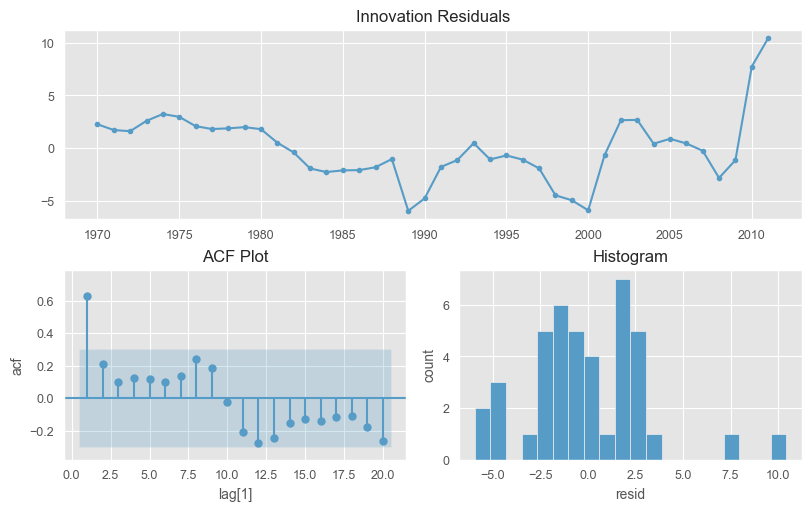

In [16]:
plot_diagnostics(forecaster=mf, target_col="Passengers", time_col="Year",
  n_lags=20)